<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke06-klinisk-praksis/01_risikomodell_logistisk_regresjon_kalibrering_shap.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 20-40 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig
- Data: syntetisk klinisk datasett
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [1]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = [('shap', 'shap')]
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# 🏥 Syntetisk risikomodell i klinisk praksis: logistisk regresjon, kalibrering og SHAP

Denne notebooken tar utgangspunkt i en enkel klinisk situasjon: Vi ønsker å anslå risiko for at en pasient tilhører en gruppe som trenger tettere oppfølging eller videre vurdering. Dataene er syntetiske, men poenget er klinisk: Hvordan går vi fra en modell som gir sannsynligheter til noe som kan brukes som beslutningsstøtte?

Logistisk regresjon er valgt her fordi den er et godt startpunkt i klinisk praksis. Den er relativt lett å forstå, lett å kalibrere og egner seg godt når målet ikke bare er høy prediksjonsytelse, men også transparens og etterprøvbarhet.

## Læringsmål
- Trene en enkel og klinisk forståelig risikomodell
- Vurdere både diskriminering (AUROC) og kalibrering (Brier/kurver)
- Tolke hva modellresultater betyr i en klinisk beslutningssituasjon
- Bruke SHAP til å utforske hvorfor modellen anslår høy eller lav risiko


### 🔧 Miljøoppsett – fungerer både lokalt og i Google Colab


In [2]:
import sys, subprocess, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("🚀 Kjører i Google Colab")
    # SHAP kan mangle i base-Colab
    try:
        import shap  # noqa: F401
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])  # type: ignore
    if not os.path.exists('AI-og-helse'):
        print("📥 Laster ned kursmateriell...")
        subprocess.check_call(["git", "clone", "https://github.com/arvidl/AI-og-helse.git"])  # type: ignore
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Byttet til mappe: {os.getcwd()}")
else:
    print("💻 Kjører i lokalt miljø")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
import shap

rng = np.random.default_rng(42)
print("✅ Miljø klart")


💻 Kjører i lokalt miljø
✅ Miljø klart


## Hvorfor bruker vi et syntetisk datasett her?

I denne notebooken bruker vi **syntetiske data**, altså data som er kunstig generert og ikke hentet fra virkelige pasienter. Det gjør vi av flere grunner:

- vi kan demonstrere sentrale ideer uten å bruke sensitive helseopplysninger
- vi kan kontrollere datastrukturen og lage et eksempel som er pedagogisk ryddig
- vi kan fokusere på modellforståelse, kalibrering og forklaringer før vi går videre til spørsmål om implementering og validering

Det syntetiske datasettet skal ikke forstås som en ferdig klinisk modell. Det skal heller ses som en forenklet øvingssituasjon der vi later som om vi har et sett pasientvariabler og et binært utfall som modellen prøver å anslå risiko for.

I praksis kan du tenke på dette som et stilisert eksempel der hver rad representerer én pasient, hver kolonne representerer ett eller flere målte forhold, og utfallet representerer om pasienten tilhører en gruppe med forhøyet sannsynlighet for et klinisk relevant utfall, for eksempel behov for videre utredning, tettere oppfølging eller økt risiko for en tilstand.


In [3]:
# Syntetiske data
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    weights=[0.7, 0.3],
    class_sep=1.0,
    random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(2250, 20) (750, 20)


## Hvordan er datasettet bygget opp?

I kodecellen over lager vi et datasett med `3000` observasjoner og `20` variabler. Av disse er `8` variabler informative, som betyr at de faktisk bidrar til å skille mellom pasienter med og uten utfallet. `4` variabler er redundante, som betyr at de i praksis inneholder overlappende informasjon. Dette er nyttig pedagogisk fordi det ligner en klinisk situasjon der flere mål kan beskrive noe av det samme.

Klassefordelingen er satt til omtrent `70/30`. Det betyr at utfallet er vanligere i én gruppe enn i den andre, noe som også er realistisk for mange kliniske problemstillinger. Vi deler deretter datasettet i trenings- og testdata for å kunne undersøke hvordan modellen oppfører seg på data den ikke har sett under trening.

Det er viktig å merke seg at variabelnavnene her ikke er kliniske. De er generiske (`Feature 0`, `Feature 1` osv.), nettopp fordi målet i denne notebooken er å forstå metode. I et reelt klinisk datasett ville vi forventet meningsfulle variabelnavn som alder, laboratorieverdier, symptomer eller funn. Da ville også tolkningen av SHAP-figuren blitt mer medisinsk konkret.

### Klinisk hovedpoeng

Syntetiske data er nyttige for å lære hvordan modeller virker. Men før en modell kan brukes i praksis, må den trenes og testes på data som faktisk representerer pasientene, målemetodene og arbeidsflyten i den kliniske settingen der den skal brukes.


## Klinisk tolkning av modellresultatene

AUROC sier noe om hvor godt modellen skiller mellom grupper, men i klinisk praksis er det ofte minst like viktig om sannsynlighetene er rimelige. En modell kan rangere pasienter godt og likevel overvurdere eller undervurdere faktisk risiko.

Derfor er kalibrering viktig: Hvis modellen anslår 30 % risiko, bør det i grove trekk bety at omtrent 30 av 100 lignende pasienter faktisk får utfallet. SHAP kan så brukes som et supplement for å undersøke hvilke variabler som trekker risikoanslaget opp eller ned for enkeltpasienter eller grupper, men slike forklaringer må alltid tolkes i lys av fagkunnskap og datagrunnlag.


AUROC: 0.838  |  Brier: 0.134


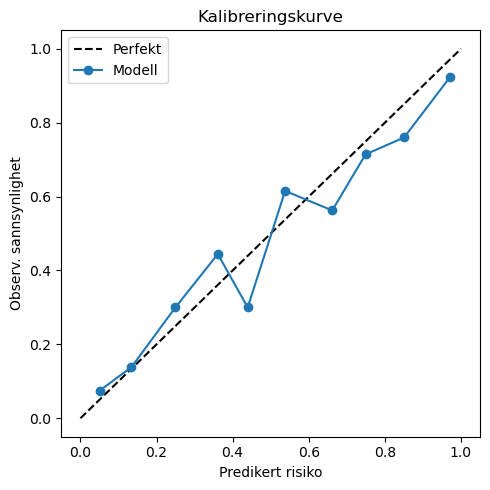

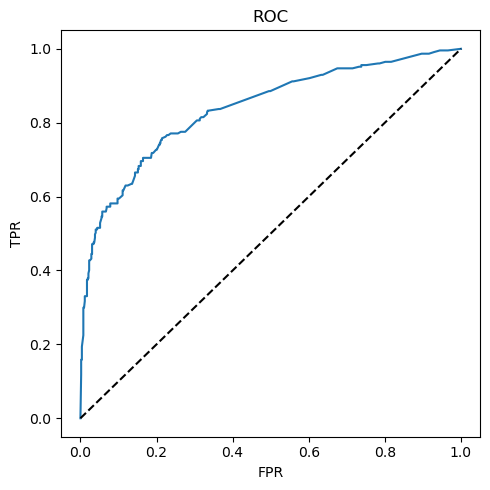

In [4]:
# Modell og kalibrering
base = LogisticRegression(max_iter=1000, solver='lbfgs')
base.fit(X_train, y_train)
cal = CalibratedClassifierCV(estimator=base, method="isotonic", cv=5)
cal.fit(X_train, y_train)

proba_test = cal.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)
brier = brier_score_loss(y_test, proba_test)
print(f"AUROC: {auc:.3f}  |  Brier: {brier:.3f}")

# Kalibreringskurve
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy='uniform')
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], 'k--', label='Perfekt')
plt.plot(prob_pred, prob_true, marker='o', label='Modell')
plt.xlabel('Predikert risiko')
plt.ylabel('Observ. sannsynlighet')
plt.title('Kalibreringskurve')
plt.legend(); plt.tight_layout(); plt.show()

# ROC-kurve
fpr, tpr, thr = roc_curve(y_test, proba_test)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC'); plt.tight_layout(); plt.show()


## Beskrivelse og tolkning av kalibreringskurve og ROC-kurve

De to figurene over viser to ulike sider av modellens kvalitet, og de svarer på to forskjellige kliniske spørsmål.

### 1. Kalibreringskurven

Kalibreringskurven sammenligner **predikert risiko** på x-aksen med **observert sannsynlighet** på y-aksen. Den stiplede diagonalen viser en ideell modell: Dersom modellen anslår 20 % risiko, bør omtrent 20 av 100 lignende pasienter faktisk få utfallet. Dersom modellen anslår 80 % risiko, bør utfallet inntreffe hos omtrent 80 av 100.

I denne figuren ligger modellen flere steder relativt nær den ideelle linjen, men ikke helt jevnt. Det betyr at modellen i grove trekk gir rimelige sannsynligheter, men at den også har områder der den over- eller undervurderer risiko. Særlig i midtre risikoområder ser vi at punktene svinger noe rundt diagonalen. Det er typisk for små eller middels store datasett og minner oss om at sannsynligheter må tolkes med varsomhet, ikke som eksakte sannheter.

Klinisk er dette viktig fordi en modell ofte brukes til å prioritere videre utredning, oppfølging eller tiltak. Da holder det ikke at modellen bare rangerer pasienter riktig; risikoanslagene bør også være noenlunde troverdige. En modell som systematisk anslår for høy risiko kan føre til for mange undersøkelser. En modell som anslår for lav risiko kan føre til at pasienter som burde vært fanget opp, ikke blir det.

Brier-scoren på `0.134` oppsummerer noe av dette i ett tall. Lavere verdi er bedre, og verdien her tyder på at modellen er brukbar, men ikke perfekt kalibrert. I praksis er poenget ikke å lese tallet isolert, men å se det sammen med kurven og med den kliniske sammenhengen modellen skal brukes i.

### 2. ROC-kurven

ROC-kurven viser forholdet mellom **sensitivitet** (TPR) og **falsk positiv-rate** (FPR) når vi varierer terskelen. Den svarer derfor på et annet spørsmål enn kalibreringskurven: Hvor godt klarer modellen å skille mellom pasienter med og uten utfallet?

Kurven ligger tydelig over diagonalen, som betyr at modellen har reell diskriminerende evne. AUROC på `0.838` er et ganske godt resultat i dette syntetiske eksempelet. Det betyr at modellen relativt ofte rangerer en tilfeldig pasient med utfallet høyere enn en tilfeldig pasient uten utfallet.

Men ROC-kurven sier ikke om en risiko på for eksempel 0.30 faktisk betyr omtrent 30 % sannsynlighet. Den sier heller ikke hvilken terskel som er riktig i klinisk bruk. Derfor trenger vi både ROC og kalibrering: ROC forteller hvor godt modellen skiller mellom grupper, mens kalibrering forteller hvor troverdige sannsynlighetene er.

### Klinisk hovedpoeng

Hvis modellen bare skulle brukes til grov sortering, kan høy diskriminering være nyttig. Hvis modellen derimot skal brukes til å støtte konkrete beslutninger, som henvisning, videre testing eller tettere oppfølging, blir kalibrering minst like viktig. Det er nettopp denne overgangen fra risikoestimat til handling som tas videre i notebook 02.


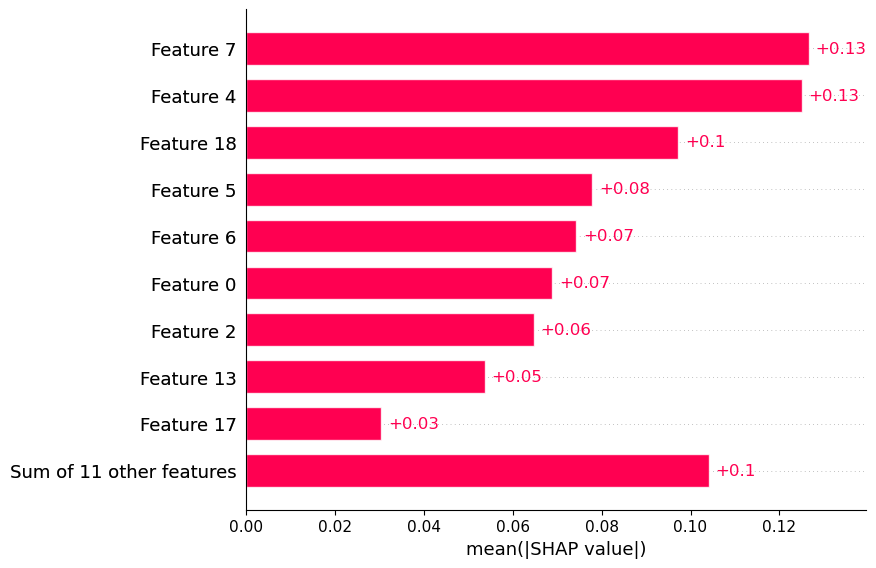

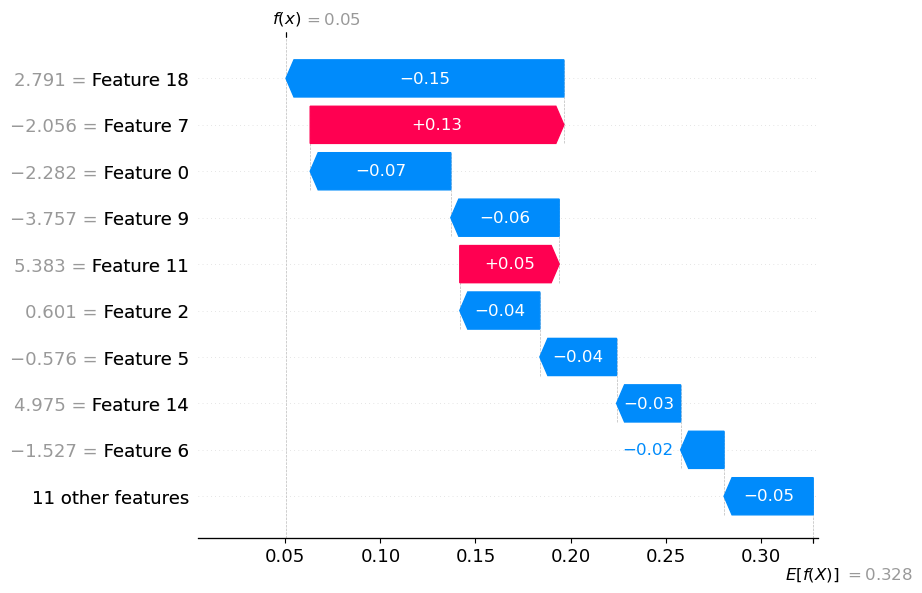

In [5]:
# SHAP-forklaringer
explainer = shap.Explainer(cal.predict_proba, X_train)
shap_values = explainer(X_test[:200])

# For binær klassifikasjon returnerer SHAP ofte forklaringer for begge klassene.
# Vi visualiserer klasse 1 (positiv klasse) når den er tilgjengelig.
if shap_values.values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

# Global oversikt (bar)
shap.plots.bar(shap_values_pos, max_display=10)

# Lokal forklaring (waterfall) – statisk figur som fungerer mer robust
# enn force plot i JupyterLab og andre miljøer uten SHAP-Javascript.
shap.plots.waterfall(shap_values_pos[0], max_display=10)


## Beskrivelse og tolkning av SHAP-figuren

SHAP-figuren viser hvilke variabler som i gjennomsnitt har størst betydning for modellens prediksjoner i utvalget vi analyserer. X-aksen viser gjennomsnittlig absolutt SHAP-verdi, altså hvor mye en variabel typisk bidrar til å trekke modellens risikoestimat opp eller ned. Jo lengre stolpe, desto større påvirkning har variabelen på modellens anslag.

I denne figuren ser vi at noen få variabler, her vist som `Feature 7`, `Feature 4`, `Feature 18` og flere andre, bidrar mer enn resten. Samtidig viser raden `Sum of 11 other features` at mye av modellens samlede informasjon også ligger spredt utover mange mindre bidrag. Det betyr at modellen ikke nødvendigvis styres av én enkelt variabel alene, men av en kombinasjon av flere forhold.

Dette er nyttig klinisk fordi det gir en første pekepinn på **hva modellen ser ut til å legge vekt på**. Dersom de viktigste variablene stemmer noenlunde med faglig forventning, kan det styrke tilliten til at modellen fanger opp relevante mønstre. Dersom de viktigste variablene virker overraskende, irrelevante eller indirekte, kan det være et signal om at modellen lærer sammenhenger som bør undersøkes nærmere.

Samtidig må SHAP tolkes med forsiktighet:

- SHAP forklarer hvordan modellen oppfører seg, ikke nødvendigvis hvordan verden faktisk fungerer.
- Høy SHAP-betydning betyr ikke at en variabel er en årsak til utfallet.
- Korrelerte variabler kan dele på eller flytte forklaringskraft mellom seg.
- Viktige variabler i modellen er ikke alltid de samme som de mest handlingsrelevante variablene for klinikeren.

I denne notebooken er variablene syntetiske og anonymt navngitt, så poenget er først og fremst metodisk: å forstå hvordan en forklaringsfigur kan brukes for å få oversikt over modellens prioriteringer. I et reelt klinisk datasett ville neste spørsmål være om disse variablene er medisinsk plausible, om de er stabile over tid, og om de kan gi utilsiktede skjevheter i ulike pasientgrupper.

### Klinisk hovedpoeng

SHAP kan være nyttig som støtte for refleksjon, kvalitetssikring og dialog mellom utviklere og klinikere. Men SHAP alene gjør ikke en modell trygg eller forklarlig nok til klinisk bruk. Forklaringer må alltid vurderes sammen med kalibrering, validering, subgruppeanalyse og den konkrete arbeidsflyten modellen skal inngå i.


<details>
<summary><strong>Refleksjon</strong></summary>

- I hvilke kliniske situasjoner er god kalibrering viktigere enn høy AUROC?
- Hva ville konsekvensen være dersom modellen systematisk overvurderer eller undervurderer risiko?
- Hvordan kan SHAP være nyttig for en kliniker, og når kan slike forklaringer bli misvisende?
- Hvilken terskel ville du valgt dersom modellen skulle brukes til videre utredning eller tettere oppfølging, og hvorfor?
- Hva måtte vært på plass før en slik modell kunne brukes som reell beslutningsstøtte i klinisk praksis?

</details>


## Oppsummering

Denne notebooken viser hvordan en enkel og klinisk forståelig modell kan brukes til å anslå risiko, hvordan vi vurderer kalibrering og diskriminering, og hvordan SHAP kan gi innsikt i hvilke variabler modellen ser ut til å legge vekt på.


### Videre i uke 06

I neste notebook går vi fra risikoanslag til klinisk handling og ser hvordan terskler og avveininger påvirker beslutningsstøtte i praksis.


### Husk

En modell kan være både nyttig og forståelig i en notebook, men må fortsatt valideres og vurderes i lys av klinisk setting før den kan brukes i praksis.
